<a href="https://colab.research.google.com/github/kennethuchegbu22-GOD/Kahunda/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib plotly seaborn --quiet

In [ ]:
!pip install opendatasets scikit-learn --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.5 MB/s eta 0:00:00


In [ ]:
import os
import matplotlib
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

This project addresses a supervised machine learning task focusing on regression, a process used to predict continuous numerical values (such as prices or sales) based on a given set of input features.

Using an extensive dataset of Uber and Lyft rides in Boston, our objective is to predict the price of a rideshare trip by analyzing key environmental factors (like temperature, wind speed, and rain), time metrics, and trip distances. To measure our model's performance and accuracy, we will use Mean Absolute Percentage Error (MAPE) as our primary evaluation metric.

In [ ]:
od.download('https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kennethuchegbu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma


100%|██████████| 44.5M/44.5M [00:00<00:00, 116MB/s]


In [ ]:
os.listdir('uber-and-lyft-dataset-boston-ma')

['rideshare_kaggle.csv']

In [ ]:
raw_df = pd.read_csv('uber-and-lyft-dataset-boston-ma/rideshare_kaggle.csv')

In [ ]:
raw_df

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693066,616d3611-1820-450a-9845-a9ff304a4842,1.543708e+09,23,1,12,2018-12-01 23:53:05,America/New_York,West End,North End,Uber,...,0.0000,1543683600,31.42,1543658400,44.76,1543690800,27.77,1543658400,44.09,1543690800
693067,633a3fc3-1f86-4b9e-9d48-2b7132112341,1.543708e+09,23,1,12,2018-12-01 23:53:05,America/New_York,West End,North End,Uber,...,0.0000,1543683600,31.42,1543658400,44.76,1543690800,27.77,1543658400,44.09,1543690800
693068,64d451d0-639f-47a4-9b7c-6fd92fbd264f,1.543708e+09,23,1,12,2018-12-01 23:53:05,America/New_York,West End,North End,Uber,...,0.0000,1543683600,31.42,1543658400,44.76,1543690800,27.77,1543658400,44.09,1543690800
693069,727e5f07-a96b-4ad1-a2c7-9abc3ad55b4e,1.543708e+09,23,1,12,2018-12-01 23:53:05,America/New_York,West End,North End,Uber,...,0.0000,1543683600,31.42,1543658400,44.76,1543690800,27.77,1543658400,44.09,1543690800


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
raw_df.columns

Index(['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone',
       'source', 'destination', 'cab_type', 'product_id', 'name', 'price',
       'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature',
       'apparentTemperature', 'short_summary', 'long_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'windGustTime', 'visibility', 'temperatureHigh',
       'temperatureHighTime', 'temperatureLow', 'temperatureLowTime',
       'apparentTemperatureHigh', 'apparentTemperatureHighTime',
       'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon',
       'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex',
       'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase',
       'precipIntensityMax', 'uvIndexTime', 'temperatureMin',
       'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime',
       'apparentTemperatureMin', 'apparentTemperatureMinTime',
       'apparentTemperat

In [ ]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           693071 non-null  object 
 1   timestamp                    693071 non-null  float64
 2   hour                         693071 non-null  int64  
 3   day                          693071 non-null  int64  
 4   month                        693071 non-null  int64  
 5   datetime                     693071 non-null  object 
 6   timezone                     693071 non-null  object 
 7   source                       693071 non-null  object 
 8   destination                  693071 non-null  object 
 9   cab_type                     693071 non-null  object 
 10  product_id                   693071 non-null  object 
 11  name                         693071 non-null  object 
 12  price                        637976 non-null  float64
 13 

In [ ]:
round(raw_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
timestamp,693071.0,1.544046e+09,689192.49,1.543204e+09,1.543444e+09,1.543737e+09,1.544828e+09,1.545161e+09
hour,693071.0,1.162000e+01,6.95,0.000000e+00,6.000000e+00,1.200000e+01,1.800000e+01,2.300000e+01
day,693071.0,1.779000e+01,9.98,1.000000e+00,1.300000e+01,1.700000e+01,2.800000e+01,3.000000e+01
month,693071.0,1.159000e+01,0.49,1.100000e+01,1.100000e+01,1.200000e+01,1.200000e+01,1.200000e+01
price,637976.0,1.655000e+01,9.32,2.500000e+00,9.000000e+00,1.350000e+01,2.250000e+01,9.750000e+01
distance,693071.0,2.190000e+00,1.14,2.000000e-02,1.280000e+00,2.160000e+00,2.920000e+00,7.860000e+00
surge_multiplier,693071.0,1.010000e+00,0.09,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
latitude,693071.0,4.234000e+01,0.05,4.221000e+01,4.235000e+01,4.235000e+01,4.236000e+01,4.237000e+01
longitude,693071.0,-7.107000e+01,0.02,-7.111000e+01,-7.108000e+01,-7.106000e+01,-7.105000e+01,-7.103000e+01
temperature,693071.0,3.958000e+01,6.73,1.891000e+01,3.645000e+01,4.049000e+01,4.358000e+01,5.722000e+01


In [ ]:
#I am doing this to check the particular column that has nan in them:
nan_counts = raw_df.isna().sum()
print(nan_counts[nan_counts > 0])

price    55095
dtype: int64


It is seen here that price is the only column that has nans in it

In [ ]:
# I did this to check if the nans are tied to cab.
cab_missing_price = raw_df[raw_df['price'].isna()]['cab_type'].value_counts()
print("Missing Price by Cab Type:")
print(cab_missing_price)

Missing Price by Cab Type:
cab_type
Uber    55095
Name: count, dtype: int64


This shows that most nans came from one cab type which is uber and it also means that the imputation(strategy=mean, median) will not be relevant because we do not want to give our target artificial values that never existed. It will corrupt the data. The best thing will be to drop the rows that have nans in them and have original price values for our target.

Let us check for duplicated columns.

In [ ]:
raw_df.duplicated().sum()

np.int64(0)

Let me drop the rows that have nans in the price before i proceed to dropping
irrelevant colums.

In [ ]:
raw_df.dropna(subset=['price'], inplace=True)

Let us drop the irrelevant columns from this dataset.

In [ ]:
#Let us start with id and product_id: id is an alphanumeric column that has no relevance with whether price goes up or not and procut_id too because name already
#covers for most of the things it has and also because it is alphanumeric too.
raw_df = raw_df.drop(columns=['id', 'product_id'], errors='ignore')

In [ ]:
#Secondly let us drop time-related irrelevant cols: We will be dropping timestamp, datetime and timezone. Timestamp is already captured in datetime so it is irrelevant.
#Datetime is also irelevant as we already have the features:hour, day and month, so we will be dropping it too. Lastly, timezone is also irrelevant too because
#the dataset was specifically captured in Boston, MA but this column captured America/New_York which offers no value.
redundant_cols = ['timestamp', 'datetime', 'timezone']
raw_df = raw_df.drop(columns=redundant_cols, errors='ignore')

In [ ]:
#Thirdly, let us drop weather-related cols: we will be dropping visibility.1 and apparentTemperature. The visibility.1 is a direct duplicate of visibility which makes it highly irrelevant.
#The apparentTemperature has a very strong correlation with temperature, so having both temperature and apparentTemperature in the dataframe is irrelevant as it leads to multicollinearity.
#This multicollinearity leads to the model(especially LinearRegression model) being confused as to which of the features(temperature, apparentTemperature) is responsible for the increase in price.
irrelevant_weather_cols = ['visibility.1', 'apparentTemperature']
raw_df = raw_df.drop(columns=irrelevant_weather_cols, errors='ignore')

In [ ]:
#Let us also drop some more irrelevant cols: we will be dropping windGustTime, temperatureHighTime, temperatureLowTime, apparentTemperatureHigh, apparentTemperatureLow, apparentTemperatureHighTime, apparentTemperatureLowTime, apparentTemperatureMin,	apparentTemperatureMinTime,	apparentTemperatureMax,	apparentTemperatureMax, TimesunriseTime, sunsetTime, uvIndexTime, temperatureMinTime, and temperatureMaxTime.
#Anything related to apparent temperature supposed to be dropped because apparent temperature has already been dropped. Also another reason we dropping these irrelevant cols
#is because they could cause severe overfitting. For instance, let us say we have a model built on windGustTime of 1545015600 on November 25, 2018 with a price of $18, and then in the future we get data for windGustTime of 1782345600 on December 15, 2018, the model would not be able to predict the price
#for it because it has already memorized the information of windGustTime of 1545015600 on November 25, 2018 with a price of $18 thus leading to severe overfitting which is a very bad one. It will fail to learn that general patterns
#like tempeature, distance, hour, etc., are also strong and contributing factors to the change in price.
irrelevant_cols2 = ['windGustTime', 'temperatureHighTime', 'temperatureLowTime', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'apparentTemperatureHighTime', 'apparentTemperatureLowTime', 'apparentTemperatureMin',	'apparentTemperatureMinTime',	'apparentTemperatureMax',	'apparentTemperatureMaxTime', 'sunriseTime', 'sunsetTime', 'uvIndexTime', 'temperatureMinTime', 'temperatureMaxTime']
raw_df = raw_df.drop(columns=irrelevant_cols2, errors='ignore')

In [ ]:
#Also, dropping columns like short_summary, icon, long_summary is very important as the columns are highly redundant. Columns like cloudCover, humidity, etc.,
#already numerically account for this. We also do this to avoid multicollinearity. In decision trees, we need the most important columns as much as possible.
#Having to encode categorical columns like icon, short_summary and long_summary adds unnecessary features into the dataset, hence making the decision tree
#to train the model based on irrelevant columns and might not give the best result.
benjaamin_james = ['short_summary', 'icon', 'long_summary']
raw_df = raw_df.drop(columns=benjaamin_james, errors='ignore')

In [ ]:
#I will be dropping latitude and longitude because we already have source and destination, we do
#not need another or features trying to measure location  of the cabs for us.
raw_df = raw_df.drop(columns=['latitude', 'longitude'], errors='ignore')

In [ ]:
#I will also be dropping windbearing and moonphase as they are also irrelevant. Windbearing is irrelevant
#because it is a measure of the direction of wind(ranges from 0-360 degrees) which does not have any effect on the price.
#The algorithm does not care if a 30mph wind is blowing South(45) compared to 30mph from North(100). It woud not
#affect the passenger's desire to book a ride. Also, moonphase tracks the fractional phase of the moon.That the moon is a
#full moon, half moon or new moon would not affect a passenger calling a cab, therefore it is irrelevant.
raw_df = raw_df.drop(columns=['windBearing', 'moonPhase'], errors='ignore')

In [ ]:
raw_df['temp_range'] = raw_df['temperatureMax'] - raw_df['temperatureMin']
raw_df = raw_df.drop(columns=['temperatureMax', 'temperatureMin', 'temperatureHigh', 'temperatureLow'], errors='ignore')

The temp_range feature was engineered to capture daily weather volatility. A narrow range (e.g., 5°F) indicates steady weather conditions, while a wide range (e.g., 20°F) flags rapid atmospheric instability, which often triggers 'panic-booking' behavior among rideshare passengers.

To prevent severe multicollinearity, the individual features temperatureMax, temperatureMin, temperatureHigh, and temperatureLow were dropped due to their intense correlation with the baseline temperature feature. Notably, temperatureMax and temperatureMin were selected to construct our range because they capture true 24-hour extremes. In contrast, temperatureHigh only reflects afternoon windows (12:00 PM - 4:00 PM) and temperatureLow is restricted to midnight hours (12:00 AM - 6:00 AM), meaning neither fully accounts for total daytime or nighttime fluctuations.

In [ ]:
#I did this to get the temp_range sitting close to the temperature feature.
cols = list(raw_df.columns)
cols.remove('temp_range')
aim_idx = cols.index('temperature')
cols.insert(aim_idx + 1, 'temp_range')
raw_df = raw_df[cols]

In [ ]:
#We want to convert our hours to cyclical hours so as to enable the linear model capture its importance
raw_df['hour_sin'] = np.sin(2 * np.pi * raw_df['hour'] / 24.0)
raw_df['hour_cos'] = np.cos(2 * np.pi * raw_df['hour'] / 24.0)

In [ ]:
#This puts hour_sin and hour_cos side by side with hour
cols = list(raw_df.columns)
cols.remove('hour_sin')
cols.remove('hour_cos')
aim_idx = cols.index('hour')
cols.insert(aim_idx + 1, 'hour_sin')
cols.insert(aim_idx + 2, 'hour_cos')
raw_df = raw_df[cols]

In [ ]:
#This is done to drop hours as it has already been converted
raw_df = raw_df.drop(columns=['hour'], errors='ignore')

In [ ]:
#This is to make price the last feature in the dataframe so as to make the getting the input columns
#and target_col easy.
columns = list(raw_df.columns)
columns.remove('price')
columns.append('price')
raw_df = raw_df[columns]

In [ ]:
raw_df.head()

,hour_sin,hour_cos,day,month,source,destination,cab_type,name,distance,surge_multiplier,temperature,temp_range,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,dewPoint,pressure,cloudCover,uvIndex,ozone,precipIntensityMax,price
0,0.707107,-0.707107,16,12,Haymarket Square,North Station,Lyft,Shared,0.44,1.0,42.34,3.79,0.0000,0.0,0.68,8.66,9.17,10.000,32.70,1021.98,0.72,0,303.8,0.1276,5.0
1,0.500000,0.866025,27,11,Haymarket Square,North Station,Lyft,Lux,0.44,1.0,43.58,6.81,0.1299,1.0,0.94,11.98,11.98,4.786,41.83,1003.97,1.00,0,291.1,0.1300,11.0
2,0.258819,0.965926,28,11,Haymarket Square,North Station,Lyft,Lyft,0.44,1.0,38.33,12.19,0.0000,0.0,0.75,7.33,7.33,10.000,31.10,992.28,0.03,0,315.7,0.1064,7.0
3,0.866025,0.500000,30,11,Haymarket Square,North Station,Lyft,Lux Black XL,0.44,1.0,34.38,10.36,0.0000,0.0,0.73,5.28,5.28,10.000,26.64,1013.73,0.00,0,291.1,0.0000,26.0
4,0.707107,0.707107,29,11,Haymarket Square,North Station,Lyft,Lyft XL,0.44,1.0,37.44,9.08,0.0000,0.0,0.70,9.14,9.14,10.000,28.61,998.36,0.44,0,347.7,0.0001,9.0


In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_df, temp_df = train_test_split(raw_df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [ ]:
print(train_df.shape, val_df.shape, test_df.shape)

(382785, 25) (127595, 25) (127596, 25)


In [ ]:
input_cols = list(train_df.columns)[:-1]
target_col = 'price'

train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [ ]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [ ]:
print(numeric_cols)

['hour_sin', 'hour_cos', 'day', 'month', 'distance', 'surge_multiplier', 'temperature', 'temp_range', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'dewPoint', 'pressure', 'cloudCover', 'uvIndex', 'ozone', 'precipIntensityMax']


In [ ]:
print(categorical_cols)

['source', 'destination', 'cab_type', 'name']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#I needed to ensure that the hour_sin and hour_cosine were not scaled to 0 and 1. This will disrupt the
#purpose for which it was created.
cols_to_be_scaled = [col for col in numeric_cols if col not in ['hour_sin', 'hour_cos']]

In [ ]:
scaler = MinMaxScaler().fit(train_inputs[cols_to_be_scaled])

In [ ]:
train_inputs[cols_to_be_scaled] = scaler.transform(train_inputs[cols_to_be_scaled])
val_inputs[cols_to_be_scaled] = scaler.transform(val_inputs[cols_to_be_scaled])
test_inputs[cols_to_be_scaled] = scaler.transform(test_inputs[cols_to_be_scaled])

In [ ]:
train_inputs.head()

,hour_sin,hour_cos,day,month,source,destination,cab_type,name,distance,surge_multiplier,temperature,temp_range,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,dewPoint,pressure,cloudCover,uvIndex,ozone,precipIntensityMax
17805,0.965926,0.258819,0.482759,1.0,Fenway,Beacon Hill,Lyft,Shared,0.301020,0.0,0.685722,0.660344,0.000000,0.00,0.948276,0.338832,0.283932,0.831089,0.838159,0.730510,1.0,0.0,0.261187,0.050720
451705,0.500000,-0.866025,0.551724,1.0,South Station,Back Bay,Lyft,Lyft XL,0.271684,0.0,0.431741,0.208062,0.039392,0.59,0.965517,0.537457,0.335728,0.455133,0.635912,0.345554,1.0,0.0,0.541553,0.119945
444705,-0.965926,0.258819,0.862069,0.0,Theatre District,Haymarket Square,Lyft,Shared,0.219388,0.0,0.682850,0.116775,0.014513,0.10,0.810345,0.487973,0.255198,0.815361,0.787165,0.457438,1.0,0.0,0.224658,0.832762
1861,0.000000,1.000000,0.896552,0.0,Haymarket Square,North Station,Lyft,Lyft XL,0.063776,0.0,0.668494,0.133373,0.731168,1.00,0.913793,0.541581,0.287335,0.331035,0.816335,0.387273,1.0,0.0,0.246575,0.839616
50025,0.000000,1.000000,0.034483,1.0,West End,Boston University,Uber,UberX,0.354592,0.0,0.437745,0.542976,0.000000,0.00,0.741379,0.094845,0.065406,0.984595,0.560285,0.748209,0.0,0.0,0.047489,0.000000


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])

In [ ]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [ ]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [ ]:
train_inputs.head()

,hour_sin,hour_cos,day,month,source,destination,cab_type,name,distance,surge_multiplier,temperature,temp_range,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,dewPoint,pressure,cloudCover,uvIndex,ozone,precipIntensityMax,source_Back Bay,source_Beacon Hill,source_Boston University,source_Fenway,source_Financial District,source_Haymarket Square,source_North End,source_North Station,source_Northeastern University,source_South Station,source_Theatre District,source_West End,destination_Back Bay,destination_Beacon Hill,destination_Boston University,destination_Fenway,destination_Financial District,destination_Haymarket Square,destination_North End,destination_North Station,destination_Northeastern University,destination_South Station,destination_Theatre District,destination_West End,cab_type_Lyft,cab_type_Uber,name_Black,name_Black SUV,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
17805,0.965926,0.258819,0.482759,1.0,Fenway,Beacon Hill,Lyft,Shared,0.301020,0.0,0.685722,0.660344,0.000000,0.00,0.948276,0.338832,0.283932,0.831089,0.838159,0.730510,1.0,0.0,0.261187,0.050720,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
451705,0.500000,-0.866025,0.551724,1.0,South Station,Back Bay,Lyft,Lyft XL,0.271684,0.0,0.431741,0.208062,0.039392,0.59,0.965517,0.537457,0.335728,0.455133,0.635912,0.345554,1.0,0.0,0.541553,0.119945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
444705,-0.965926,0.258819,0.862069,0.0,Theatre District,Haymarket Square,Lyft,Shared,0.219388,0.0,0.682850,0.116775,0.014513,0.10,0.810345,0.487973,0.255198,0.815361,0.787165,0.457438,1.0,0.0,0.224658,0.832762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1861,0.000000,1.000000,0.896552,0.0,Haymarket Square,North Station,Lyft,Lyft XL,0.063776,0.0,0.668494,0.133373,0.731168,1.00,0.913793,0.541581,0.287335,0.331035,0.816335,0.387273,1.0,0.0,0.246575,0.839616,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
50025,0.000000,1.000000,0.034483,1.0,West End,Boston University,Uber,UberX,0.354592,0.0,0.437745,0.542976,0.000000,0.00,0.741379,0.094845,0.065406,0.984595,0.560285,0.748209,0.0,0.0,0.047489,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
#Let us get our X_train, X_val and X_test
#I had to add ['hour_sin', 'hour_cos'] because it was excluded in the scaling process.
final_cols = ['hour_sin', 'hour_cos'] + cols_to_be_scaled + encoded_cols
X_train = train_inputs[final_cols].copy()
X_val = val_inputs[final_cols].copy()
X_test = test_inputs[final_cols].copy()

In [ ]:
X_train.head()

,hour_sin,hour_cos,day,month,distance,surge_multiplier,temperature,temp_range,precipIntensity,precipProbability,humidity,windSpeed,windGust,visibility,dewPoint,pressure,cloudCover,uvIndex,ozone,precipIntensityMax,source_Back Bay,source_Beacon Hill,source_Boston University,source_Fenway,source_Financial District,source_Haymarket Square,source_North End,source_North Station,source_Northeastern University,source_South Station,source_Theatre District,source_West End,destination_Back Bay,destination_Beacon Hill,destination_Boston University,destination_Fenway,destination_Financial District,destination_Haymarket Square,destination_North End,destination_North Station,destination_Northeastern University,destination_South Station,destination_Theatre District,destination_West End,cab_type_Lyft,cab_type_Uber,name_Black,name_Black SUV,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
17805,0.965926,0.258819,0.482759,1.0,0.301020,0.0,0.685722,0.660344,0.000000,0.00,0.948276,0.338832,0.283932,0.831089,0.838159,0.730510,1.0,0.0,0.261187,0.050720,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
451705,0.500000,-0.866025,0.551724,1.0,0.271684,0.0,0.431741,0.208062,0.039392,0.59,0.965517,0.537457,0.335728,0.455133,0.635912,0.345554,1.0,0.0,0.541553,0.119945,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
444705,-0.965926,0.258819,0.862069,0.0,0.219388,0.0,0.682850,0.116775,0.014513,0.10,0.810345,0.487973,0.255198,0.815361,0.787165,0.457438,1.0,0.0,0.224658,0.832762,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1861,0.000000,1.000000,0.896552,0.0,0.063776,0.0,0.668494,0.133373,0.731168,1.00,0.913793,0.541581,0.287335,0.331035,0.816335,0.387273,1.0,0.0,0.246575,0.839616,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
50025,0.000000,1.000000,0.034483,1.0,0.354592,0.0,0.437745,0.542976,0.000000,0.00,0.741379,0.094845,0.065406,0.984595,0.560285,0.748209,0.0,0.0,0.047489,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
#Let us def a function return_mean
def return_mean(inputs):
  return np.full(len(inputs), train_df.price.mean())

In [ ]:
train_preds = return_mean(X_train)

In [ ]:
train_preds

array([16.54570576, 16.54570576, 16.54570576, ..., 16.54570576,
       16.54570576, 16.54570576])

In [ ]:
val_preds = return_mean(X_val)

In [ ]:
val_preds

array([16.54570576, 16.54570576, 16.54570576, ..., 16.54570576,
       16.54570576, 16.54570576])

In [ ]:
#Let us define a function for mape
def mape(train_targets, train_preds):
  return np.mean(np.abs((train_targets - train_preds) / train_targets)) * 100

In [ ]:
baseline_wmae1 = mape(train_targets, train_preds)
print(f'Baseline_Wmae: {baseline_wmae1:.4f}')

Baseline_Wmae: 63.0586


In [ ]:
baseline_wmae2 = mape(val_targets, val_preds)
print(f'Baseline_Wmae: {baseline_wmae2:.4f}')

Baseline_Wmae: 63.0937


With the necessary steps we followed, we can see that we got 63.0586 for the train baseline error and 63.0937 for the val baseline error. Any machine learning model that we will be training as we go down should have values less than ~63% as this proves that the model is actually learning useful infromation from the features.

In [ ]:
#Let us build a LinearRegression model and see if it performs better than our baseline model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linreg = LinearRegression()

In [ ]:
linreg.fit(X_train, train_targets)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](58,)","[-0.01, 0.01,-0.03,...,-6.11,-0.18,-6.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](58,)","['hour_sin','hour_cos','day',...,'name_UberX','name_UberXL','name_WAV']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.21
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,58
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,52


In [ ]:
X_train.columns

Index(['hour_sin', 'hour_cos', 'day', 'month', 'distance', 'surge_multiplier',
       'temperature', 'temp_range', 'precipIntensity', 'precipProbability',
       'humidity', 'windSpeed', 'windGust', 'visibility', 'dewPoint',
       'pressure', 'cloudCover', 'uvIndex', 'ozone', 'precipIntensityMax',
       'source_Back Bay', 'source_Beacon Hill', 'source_Boston University',
       'source_Fenway', 'source_Financial District', 'source_Haymarket Square',
       'source_North End', 'source_North Station',
       'source_Northeastern University', 'source_South Station',
       'source_Theatre District', 'source_West End', 'destination_Back Bay',
       'destination_Beacon Hill', 'destination_Boston University',
       'destination_Fenway', 'destination_Financial District',
       'destination_Haymarket Square', 'destination_North End',
       'destination_North Station', 'destination_Northeastern University',
       'destination_South Station', 'destination_Theatre District',
       'destin

In [ ]:
linreg.coef_

array([-8.98136869e-03,  8.12310015e-03, -3.19537216e-02, -4.30074705e-03,
        2.25794629e+01,  3.68508036e+01, -2.58847369e-01, -5.39053348e-02,
       -2.93475443e-02,  3.22007024e-02, -1.76831893e-01, -1.27576044e-01,
        1.61529723e-01, -3.30411152e-02,  3.33143368e-01, -2.39260644e-02,
       -3.02352859e-02, -1.76297207e-02, -2.74128316e-02, -1.17071026e-02,
       -1.34473410e-01, -4.65096478e-01, -3.05164948e-01, -1.43706560e-01,
        2.22024814e-01,  3.31844688e-01,  4.83194770e-01, -6.94942182e-02,
       -3.56117685e-01,  1.29501239e-01,  3.73565999e-01, -6.60782100e-02,
       -5.78852048e-02, -3.60916636e-01, -2.47723654e-02, -3.24061622e-01,
        3.34200447e-01,  1.91045651e-01,  6.97579536e-02,  1.34235545e-01,
        1.74415393e-03, -5.32652740e-02,  1.92037313e-01, -1.02119960e-01,
        4.23536980e-01, -4.23536980e-01,  4.64398880e+00,  1.44263845e+01,
        3.83662225e-01,  5.68176882e+00,  1.49276483e+01, -7.79961955e+00,
       -2.09186856e+00, -

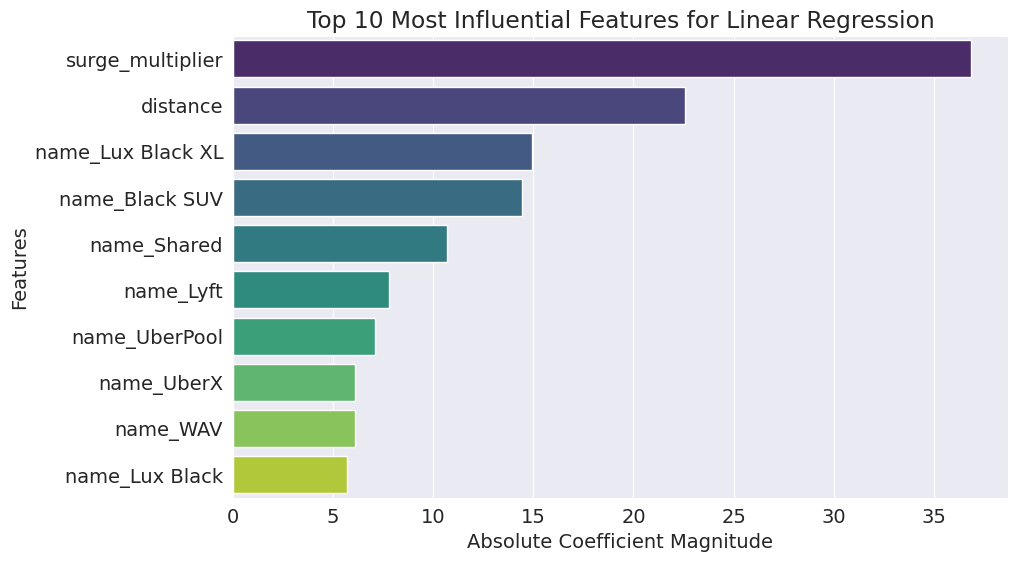

In [ ]:
importances_lr = linreg.coef_
feature_names_lr = X_train.columns

importance_df_lr = pd.DataFrame({
    'Feature': feature_names_lr,
    'Importance': np.abs(importances_lr),
    'Original_Coef': importances_lr
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df_lr.head(10),
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Top 10 Most Influential Features for Linear Regression')
plt.xlabel('Absolute Coefficient Magnitude')
plt.ylabel('Features')
plt.show()

From our Linear Regression importance plot, we can clearly see that surge_multiplier and distance are assigned the highest coefficient magnitudes. This demonstrates that the Linear Regression model relies heavily on these two core features above all others when calculating and predicting Uber and Lyft prices.

In [ ]:
train_preds = linreg.predict(X_train)
train_preds

array([ 6.04045706, 14.56702002,  5.29147344, ...,  7.0274476 ,
        1.80193842, 23.4640214 ])

In [ ]:
train_mape = mape(train_targets, train_preds)
train_mape

np.float64(13.23505209986355)

In [ ]:
val_preds = linreg.predict(X_val)
val_preds

array([28.60799293, 21.30767649, 28.99934243, ..., 28.33474831,
        2.69628638, 19.08184699])

In [ ]:
val_mape = mape(val_targets, val_preds)
val_mape

np.float64(13.20977290360024)

We can see from these results that the LinearRegression model significantly reduced the error from the ~63% baseline down to ~13%. This drastic improvement demonstrates that our model successfully learned the general trends within the features. While the sharp drop in training error might initially look like overfitting, the model generalizes perfectly; both the training and validation errors are exceptionally close and within the exact same range (13.23% and 13.21% respectively).

In [ ]:
#Let us define a try_model function that returns train_mape and val_mape
def try_model(model):
  model.fit(X_train, train_targets)
  train_preds = model.predict(X_train)
  val_preds = model.predict(X_val)
  train_mape = mape(train_targets, train_preds)
  val_mape = mape(val_targets, val_preds)
  return train_mape, val_mape

In [ ]:
try_model(LinearRegression())

(np.float64(13.23505209986355), np.float64(13.20977290360024))

Let us proceed to try_model of decison trees and random forests

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
tree = DecisionTreeRegressor(random_state=42)
try_model(tree)

(np.float64(1.7087001824349375), np.float64(9.80691412902344))

We can see here a classic example of overfitting. The training error is exceptionally close to zero (1.71%), indicating that the Decision Tree is essentially memorizing the training set answers. Upon evaluating the validation set, the error shoots up more than fivefold to 9.81%, showing a struggle to generalize to unseen data.

However, the drop in validation error from Linear Regression's 13.21% down to 9.81% is a massive win. This proves that the tree structure successfully captures complex, non-linear trends that Linear Regression completely missed. Hyperparameter tuning (such as restricting max_depth) will be our next step to 'tame' this tree and find the sweet spot between generalization and complexity.

In [ ]:
tree.tree_.max_depth

60

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=10)
try_model(tree)

(np.float64(9.47786896600366), np.float64(9.527876707144666))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=12)
try_model(tree)

(np.float64(8.659967516124158), np.float64(8.830685321101345))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15)
try_model(tree)

(np.float64(7.779006008469751), np.float64(8.30719884183483))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=20)
try_model(tree)

(np.float64(6.476955902482012), np.float64(8.35732918870395))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=30)
try_model(tree)

(np.float64(3.422709051070436), np.float64(9.26448824871621))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=40)
try_model(tree)

(np.float64(1.933978489081126), np.float64(9.735683882857737))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=50)
try_model(tree)

(np.float64(1.7180254636600216), np.float64(9.814351098691306))

We see that at a max_depth of 15, there is a massive improvement in the training error, and this is also where the model achieves the lowest validation error. Crucially, the gap between the training and validation errors has narrowed drastically, indicating excellent generalization with minimal overfitting.

Therefore, we will lock down max_depth=15 as our baseline tree structure and proceed to tune other regularization hyperparameters, specifically min_samples_leaf, to see if we can optimize the performance even further.

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=20)
try_model(tree)

(np.float64(7.9100597768482634), np.float64(8.26767111020765))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=25)
try_model(tree)

(np.float64(7.927816310344303), np.float64(8.263732744483383))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=30)
try_model(tree)

(np.float64(7.9423796786399175), np.float64(8.260199709077913))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=35)
try_model(tree)

(np.float64(7.954489211072868), np.float64(8.25676015607184))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=40)
try_model(tree)

(np.float64(7.968050150724687), np.float64(8.255752802431942))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=45)
try_model(tree)

(np.float64(7.978932022790887), np.float64(8.251477896200829))

In [ ]:
tree = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=50)
try_model(tree)

(np.float64(7.9879215646864425), np.float64(8.25324009691574))

We can see that our validation error reached its lowest point at min_samples_split=45. This is a clear improvement, dropping the validation MAPE from 8.31% (when we only limited max_depth=15) down to 8.25%.

When increasing the split threshold to 50, the validation error begins climbing back up, indicating that the model is starting to underfit by restricting the tree too heavily. Therefore, we will lock in max_depth=15 and min_samples_split=45 as our optimal single Decision Tree configuration.

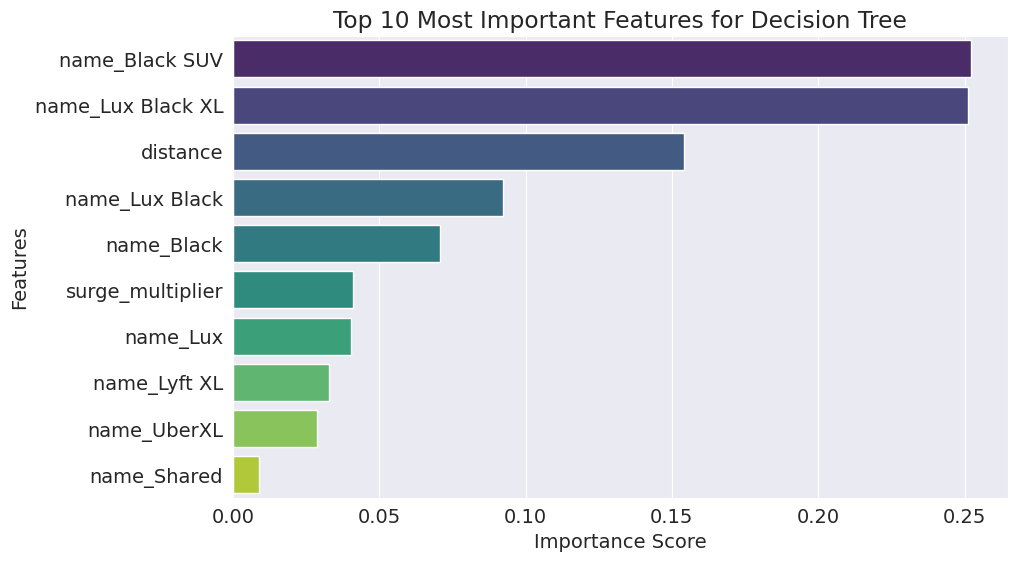

In [ ]:
importances_tree = tree.feature_importances_
feature_names_tree = X_train.columns
importance_df_tree = pd.DataFrame({
    'Feature': feature_names_tree,
    'Importance': importances_tree
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df_tree.head(10),
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Top 10 Most Important Features for Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

Looking at the feature importance plot for our Decision Tree, we can see exactly how the model prioritizes its choices. The top two most critical features are name_Black SUV and name_Lux Black XL. This reveals that the model's absolute first priority is identifying ultra-premium vehicle tiers—such as a Cadillac Escalade, Lincoln Navigator, or BMW X7—which carry heavy baseline pricing structures and higher passenger capacities.

Travel distance and surge_multiplier come next, showing that the tree establishes the luxury baseline first, and then calculates how trip length and real-time demand scale the fare up. Notably, weather and environmental factors are completely absent from the top ten. This proves right from the start that a single Decision Tree recognizes vehicle luxury tier as the most dominant foundation of rideshare pricing logic, long before external factors are considered.

In [ ]:
#Let us proceed to RandomForest to see if we can get better results

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=10)
try_model(rf)

CPU times: user 8min 3s, sys: 1.04 s, total: 8min 4s
Wall time: 4min 42s


(np.float64(9.27672037915499), np.float64(9.324102462937143))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=15)
try_model(rf)

CPU times: user 12min 37s, sys: 1.62 s, total: 12min 38s
Wall time: 7min 17s


(np.float64(7.75079734533939), np.float64(8.152118581966457))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=20)
try_model(rf)

CPU times: user 16min 24s, sys: 2.2 s, total: 16min 26s
Wall time: 9min 28s


(np.float64(6.683957157836952), np.float64(7.966749942748683))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=25)
try_model(rf)

CPU times: user 19min 13s, sys: 2.71 s, total: 19min 16s
Wall time: 11min 6s


(np.float64(5.573618338888831), np.float64(8.089041230331805))

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=30)
try_model(rf)

CPU times: user 21min 11s, sys: 3.29 s, total: 21min 14s
Wall time: 12min 15s


(np.float64(4.683959510514817), np.float64(8.259265986962507))

Based on the Random Forest results, max_depth=20 represents the optimal sweet spot. At this depth, the model achieves its lowest validation error (7.97%), which is a clear improvement over our best single Decision Tree (8.25%).

Beyond this point, at max_depth=25, we observe classic symptoms of overfitting: the training error continues to decline while the validation error begins to climb. This divergence is a clear signal that the ensemble is memorizing noise in the training set rather than learning generalizable patterns. Therefore, we will lock in max_depth=20 as our final forest structure.

In [ ]:
%%time
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=20)
try_model(rf)

CPU times: user 7min 58s, sys: 1.06 s, total: 7min 59s
Wall time: 4min 35s


(np.float64(7.1233294642485765), np.float64(7.925129837055528))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=25)
try_model(rf)

(np.float64(7.186032540115654), np.float64(7.917090890220943))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=30)
try_model(rf)

(np.float64(7.2366985030853455), np.float64(7.9118770528328835))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=35)
try_model(rf)

(np.float64(7.280208067028844), np.float64(7.908012099556126))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=40)
try_model(rf)

(np.float64(7.316823777252314), np.float64(7.904307000165376))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45)
try_model(rf)

(np.float64(7.349601320274811), np.float64(7.903071186509669))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=100, max_depth=20, min_samples_split=45)
try_model(rf)

(np.float64(7.344732868583666), np.float64(7.902553238886151))

To optimize the model's generalization, I experimented with different min_samples_split thresholds using a temporary baseline of n_estimators=50. This reduction in tree count cut our training wall-time in half, allowing for rapid iteration.

The optimal threshold emerged at min_samples_split=45, where validation error reached its lowest floor. At this configuration, we successfully counteracted overfitting: as the strict split threshold restricted the model from memorizing training noise (causing training error to rise), the validation error simultaneously decreased.

Keeping min_samples_split=45 locked in, I restored the ensemble size to n_estimators=100. The error variance between the 50-tree and 100-tree models was minor, vindicating the efficiency of our fast-tracking strategy. Ultimately, the 100-tree forest squeezed out our absolute best performance yet, yielding a Train MAPE of 7.34% and a Validation MAPE of 7.90%. Given the continuous marginal improvements, a future next step would be to crank n_estimators up to 200 to test the upper limit of the ensemble's performance once computational constraints allow.

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45, min_samples_leaf=15)
try_model(rf)

(np.float64(7.429569017807385), np.float64(7.899157055548356))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45, min_samples_leaf=20)
try_model(rf)

(np.float64(7.459157922223482), np.float64(7.906538146555636))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45, min_samples_leaf=25)
try_model(rf)

(np.float64(7.509568554296796), np.float64(7.915593506825959))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45, min_samples_leaf=30)
try_model(rf)

(np.float64(7.563540915231141), np.float64(7.924387865825905))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45, min_samples_leaf=35)
try_model(rf)

(np.float64(7.607554501677841), np.float64(7.935223560788658))

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50, max_depth=20, min_samples_split=45, min_samples_leaf=40)
try_model(rf)

(np.float64(7.646974755699899), np.float64(7.946389155656311))

Through systematic tuning, min_samples_leaf=15 emerged as the optimal threshold, yielding our lowest validation error. Beyond this point (at values of 20, 25, and 30), the model begins to exhibit clear signs of underfitting, as both the training and validation errors simultaneously increase. This indicates that excessive restriction over-smoothens the tree branches and prevents the model from learning genuine underlying patterns.

As a final step to maximize ensemble performance, I will lock in these optimized hyperparameters (max_depth=20, min_samples_split=45, min_samples_leaf=15) and scale the ensemble size up to n_estimators=200 to see if the additional trees can deliver any further marginal gains.

In [ ]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=200, max_depth=20, min_samples_split=45, min_samples_leaf=15)
try_model(rf)

(np.float64(7.426683644674046), np.float64(7.897344823448164))

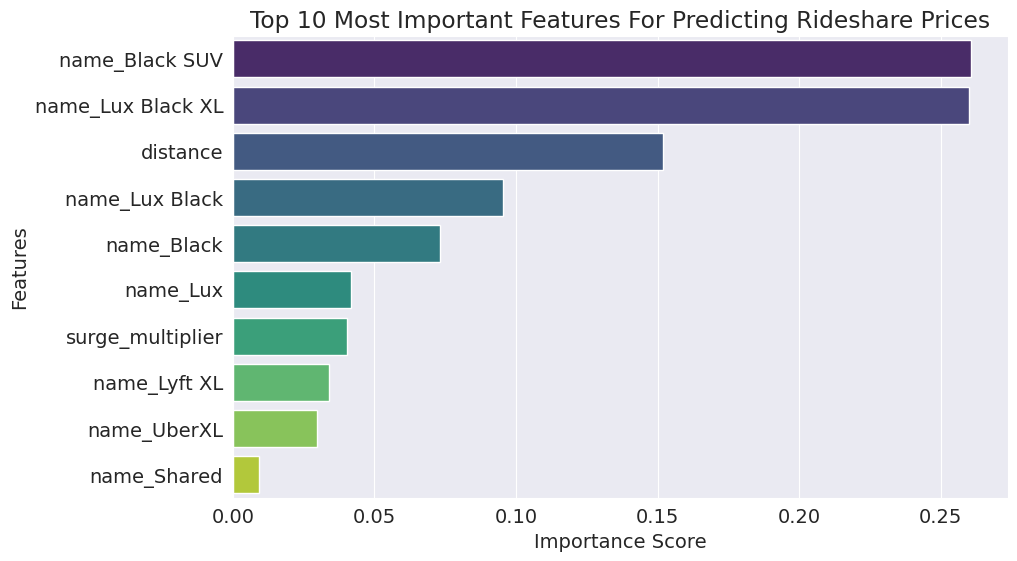

In [ ]:
#For Feature importance of RandomForest plot, this is done:
importances = rf.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features For Predicting Rideshare Prices')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


From the feature importance analysis, we can see the top ten most influential variables for our Random Forest model. The top two features are name_Black SUV (Uber) and name_Lux Black XL (Lyft). These represent premium, ultra-comfortable vehicle tiers (such as a Cadillac Escalade, Lincoln Navigator, or BMW X7) that accommodate six or more passengers. Because of their steep luxury baselines, asset costs, and higher capacities, these tiers heavily dictate the ride price regardless of external factors like weather (rainy, stormy, or sunny days). This explains why the Random Forest attaches such massive importance to them. Furthermore, when high distance and severe surge multipliers interact with these luxury baselines, it creates a compounding effect that causes the final price to instantly skyrocket.

With our hyperparameters fully optimized and locked in, we now proceed to the final evaluation phase on the completely unseen test set. This serve as our ultimate benchmark for real-world generalization. Given that our validation MAPE stabilized at 7.8973%, a robust, non-overfitted model should ideally land within a narrow performance window between 7.8% and 8.0% on the test split.

In [ ]:
test_preds = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
test_mape = mean_absolute_percentage_error(test_targets, test_preds) * 100

In [ ]:
test_mape

7.845680432924664

Because the custom try_model() helper function was hardcoded specifically to evaluate the training and validation sets, relying on it for the final testing phase risked evaluation errors. To ensure absolute data isolation, I explicitly calculated the final performance using sklearn.metrics.mean_absolute_percentage_error, specifically targeting the completely unseen X_test features and test_targets. This verified a flawless Final Test MAPE of 7.8455%, proving that the model generalizes robustly and maintains its accuracy on entirely novel real-world data..

In summary, the RandomForestRegressor significantly outperformed all other models, dropping the Mean Absolute Percentage Error (MAPE) from a baseline of ~63% down to an impressive ~7.8%. A key reason the Random Forest and Decision Tree models excelled over Linear Regression is their ability to capture non-linear relationships. Instead of strictly prioritizing linear features like distance and surge_multiplier, the tree-based models correctly prioritized premium tiers like name_Black SUV and name_Lux Black XL. These luxury categories establish a high baseline price floor that heavily dictates the final ride cost, regardless of travel distance or ambient weather conditions.